<a href="https://colab.research.google.com/github/romeurf/DipRadar/blob/main/ml_training/DipRadar_Training_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 DipRadar — ML Training (Colab)

Pipeline completo de treino dos modelos ML que correm no Railway.

**Outputs gerados e pushed para GitHub:**
- `dip_models_v3.pkl` → bundle do modelo (joblib)
- `ml_report_v3.json` → métricas e metadados do treino
- `ml_training_base.parquet` → dataset de treino completo

**Fluxo (correr em ordem):**
1. Célula 1 — Secrets + clone do repo + install deps
2. Célula 2 — Download de preços via yfinance (ETFs + ~800 tickers do universo)
3. Célula 2.5 — Enriquecimento de sectores via yfinance (sem sectors.py)
4. Célula 3 — Build do dataset de treino (features + targets)
5. Célula 4 — Walk-forward CV + seleção do champion
6. Célula 5 — Treino full + calibrador isotónico
7. Célula 6 — Bundle + Report
8. Célula 7 — Guardar parquet actualizado
9. Célula 8 — Push automático para GitHub (Railway redeploy automático)

## ⚙️ Célula 1 — Setup: secrets, clone, install deps

In [2]:
import os, subprocess, sys
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_API_KEY')
REPO_OWNER   = 'romeurf'
REPO_NAME    = 'DipRadar'
BRANCH       = 'main'

assert GITHUB_TOKEN, 'Falta GITHUB_TOKEN nos secrets do Colab'
print('✅ Secrets carregados')

REPO_URL = f'https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git'
REPO_DIR = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', '--depth=1', '-b', BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull', 'origin', BRANCH], check=True)

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'✅ Repo em {REPO_DIR}')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'joblib', 'scikit-learn', 'lightgbm', 'xgboost',
                'pandas', 'pyarrow', 'yfinance', 'imbalanced-learn'], check=True)
print('✅ Dependências instaladas')

✅ Secrets carregados
✅ Repo em /content/DipRadar
✅ Dependências instaladas


## 🌐 Célula 2 — Download de preços via yfinance (~800 tickers)

In [3]:
import yfinance as yf
import pandas as pd
from pathlib import Path
from ml_training.config import DEFAULT_ETF, SECTOR_ETF
from ml_training.price_fetch import load_etf_cache

REPO_PATH     = Path(REPO_DIR)
ETF_CACHE_DIR = REPO_PATH / 'ml_training' / 'etf_cache'
ETF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

etf_tickers = sorted(set([DEFAULT_ETF] + list(SECTOR_ETF.values())))
print(f'ETFs a descarregar: {etf_tickers}')

etf_cache = load_etf_cache(
    etfs=etf_tickers,
    start='2018-01-01',
    cache_dir=ETF_CACHE_DIR,
)

print(f'\n✅ ETF cache: {len(etf_cache)}/{len(etf_tickers)} ETFs carregados')
if len(etf_cache) == 0:
    raise RuntimeError('Nenhum ETF carregado — verifica a ligação à Internet no Colab.')

ETFs a descarregar: ['SPY', 'XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']


[*********************100%***********************]  12 of 12 completed



✅ ETF cache: 12/12 ETFs carregados


In [4]:
try:
    from universe import (
        _SP500_FALLBACK, _NASDAQ100_FALLBACK, _STOXX200, _FTSE100,
        USER_PORTFOLIO, USER_WATCHLIST, ETF_TICKERS
    )
    _raw = USER_PORTFOLIO + USER_WATCHLIST + _SP500_FALLBACK + _NASDAQ100_FALLBACK + _STOXX200 + _FTSE100
    _seen = set()
    all_tickers = []
    for t in _raw:
        t = t.strip().upper()
        if t and t not in _seen and t not in ETF_TICKERS:
            _seen.add(t)
            all_tickers.append(t)
    all_tickers = sorted(all_tickers)
    print(f'✅ universe.py: {len(all_tickers)} tickers')
except Exception as e:
    print(f'⚠️  universe.py falhou ({e}) — lista mínima')
    ETF_TICKERS = set()
    all_tickers = sorted(['AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA','BRK-B',
        'JNJ','UNH','LLY','ABBV','MRK','ABT','TMO','DHR',
        'JPM','BAC','WFC','GS','MS','BLK',
        'PG','KO','PEP','WMT','COST','MCD','HD','TGT',
        'XOM','CVX','COP','SLB','NEE','DUK','SO',
        'CAT','DE','HON','MMM','GE','RTX','VZ','T','CMCSA',
        'AMT','PLD','EQIX','LIN','APD','SHW',
        'NVO','ADBE','UBER','ADP','CRM','CRWD','PLTR','NOW',])

✅ universe.py: 704 tickers


In [5]:
from ml_training.price_fetch import fetch_ohlcv_batch
from datetime import date

START_DATE = '2018-01-01'
END_DATE   = date.today().strftime('%Y-%m-%d')

print(f'A descarregar preços de {len(all_tickers)} tickers...')
price_cache = fetch_ohlcv_batch(
    tickers_list=all_tickers,
    start=START_DATE,
    end=END_DATE,
    batch_size=40,
    progress_log=True,
)
not_found = [t for t in all_tickers if t not in price_cache]
print(f'\n✅ Price cache: {len(price_cache)}/{len(all_tickers)} tickers')
print(f'   Não encontrados: {len(not_found)}')

A descarregar preços de 704 tickers...


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ANSS']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BCR']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2026-05-06)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CRH.I']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2026-05-06)')
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['CTLT', 'DFS', 'DAY', 'CSGN.SW']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['EVR.L']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['FCA.MI', 'FI']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfina


✅ Price cache: 678/704 tickers
   Não encontrados: 26


## 🗂️ Célula 2.5 — Enriquecimento de sectores via yfinance

In [6]:
import time

try:
    from universe import TICKER_SECTOR as _STATIC_SECTOR_MAP
    print(f'✅ universe.TICKER_SECTOR: {len(_STATIC_SECTOR_MAP)} entradas estáticas')
except ImportError:
    _STATIC_SECTOR_MAP = {}
    print('ℹ️  TICKER_SECTOR não existe — sector 100% via yfinance')

sector_map: dict[str, str] = {}
missing_sector = [t for t in price_cache if t not in _STATIC_SECTOR_MAP]
print(f'\nA buscar sector para {len(missing_sector)} tickers...')

found = 0; errors = 0
for i, ticker in enumerate(missing_sector):
    try:
        info_full = yf.Ticker(ticker).info
        sec = info_full.get('sector') or info_full.get('sectorKey') or ''
        sector_map[ticker] = sec if sec else 'Unknown'
        if sec: found += 1
    except Exception:
        sector_map[ticker] = 'Unknown'; errors += 1
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(missing_sector)} | ok={found} erros={errors}')
        time.sleep(0.3)

full_sector_map: dict[str, str] = {**_STATIC_SECTOR_MAP, **sector_map}
from collections import Counter
dist = Counter(v for v in full_sector_map.values() if v and v != 'Unknown')
print(f'\n✅ Sector map: {len(full_sector_map)} tickers, {sum(dist.values())} com sector')

def get_ticker_sector(ticker: str) -> str:
    return full_sector_map.get(ticker, 'Unknown') or 'Unknown'

print('✅ get_ticker_sector() disponível')

ℹ️  TICKER_SECTOR não existe — sector 100% via yfinance

A buscar sector para 678 tickers...
  50/678 | ok=50 erros=0
  100/678 | ok=100 erros=0
  150/678 | ok=150 erros=0
  200/678 | ok=200 erros=0
  250/678 | ok=250 erros=0
  300/678 | ok=300 erros=0
  350/678 | ok=350 erros=0
  400/678 | ok=399 erros=0
  450/678 | ok=448 erros=0
  500/678 | ok=498 erros=0
  550/678 | ok=548 erros=0
  600/678 | ok=596 erros=0
  650/678 | ok=646 erros=0

✅ Sector map: 678 tickers, 674 com sector
✅ get_ticker_sector() disponível


## 🏗️ Célula 3 — Build do dataset de treino

**v3.1 changes:**
- Target: `close_60d` (close-to-close vs SPY close-to-close) — comparação justa
- Winsorize `alpha_60d` com clip absoluto `[-0.5, 2.0]` antes do treino
- Subsample 2020: máximo 2 000 alertas por ano (2020 gerou 9 188 — distorce pesos temporais)

In [9]:
import numpy as np
import math

from ml_training.config import (
    DEFAULT_ETF, SECTOR_ETF, HORIZON_DAYS,
    MOMENTUM_FEATURES, NEW_FEATURES_V31,
    WINSOR_ABS_LO, WINSOR_ABS_HI,
)
from ml_features import (
    FEATURE_COLUMNS, _FALLBACK, add_derived_features, add_momentum_features
)

# ── Funções auxiliares ───────────────────────────────────────────

def _rsi(closes: pd.Series, period: int = 14) -> float:
    if len(closes) < period + 1:
        return float(_FALLBACK.get('rsi_14', 50.0))
    delta = closes.diff().dropna()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    rsi_val = (100 - 100 / (1 + rs)).iloc[-1]
    return float(rsi_val) if pd.notna(rsi_val) else float(_FALLBACK.get('rsi_14', 50.0))

def _atr_ratio(hist: pd.DataFrame, period: int = 14) -> float:
    if len(hist) < period + 1:
        return float(_FALLBACK.get('atr_ratio', 0.02))
    tr = pd.concat([
        hist['High'] - hist['Low'],
        (hist['High'] - hist['Close'].shift()).abs(),
        (hist['Low'] - hist['Close'].shift()).abs()
    ], axis=1).max(axis=1)
    atr = tr.rolling(period).mean().iloc[-1]
    close = hist['Close'].iloc[-1]
    return float(atr / close) if close > 0 else float(_FALLBACK.get('atr_ratio', 0.02))

def _volume_spike(hist: pd.DataFrame, window: int = 20) -> float:
    if len(hist) < window:
        return 1.0
    avg = hist['Volume'].iloc[-window:].mean()
    last = hist['Volume'].iloc[-1]
    return float(last / avg) if avg > 0 else 1.0

def build_v2_features(hist: pd.DataFrame, alert_date: pd.Timestamp) -> dict:
    h = hist[hist.index <= alert_date]
    if h.empty: return {}
    close = h['Close'].iloc[-1]
    high_52w = h['High'].iloc[-252:].max() if len(h) >= 5 else close
    prev_close = h['Close'].iloc[-2] if len(h) >= 2 else close
    drop_today = (close / prev_close - 1) if prev_close > 0 else 0.0
    drawdown_52w = (close / high_52w - 1) if high_52w > 0 else 0.0
    return {
        'drop_pct_today': float(drop_today),
        'drawdown_52w': float(drawdown_52w),
        'rsi_14': _rsi(h['Close']),
        'atr_ratio': _atr_ratio(h),
        'volume_spike': _volume_spike(h),
    }

# ── TARGET: close_60d (close-to-close, não high-to-high) ─────────
# Comparação justa com SPY no mesmo dia: usamos Close do dia N+60
# em vez do High máximo da janela (max_return_60d era optimista).

def build_targets_close(alert_date: pd.Timestamp, hist: pd.DataFrame,
                        horizon: int = HORIZON_DAYS) -> dict:
    """Return do Close no dia +horizon (close-to-close)."""
    entry_slice = hist[hist.index <= alert_date]
    if entry_slice.empty:
        return {'close_60d': float('nan'), 'max_drawdown_60d': float('nan')}
    entry_price = float(entry_slice['Close'].iloc[-1])
    if entry_price <= 0:
        return {'close_60d': float('nan'), 'max_drawdown_60d': float('nan')}
    fwd = hist[
        (hist.index > alert_date) &
        (hist.index <= alert_date + pd.Timedelta(days=horizon))
    ]
    if len(fwd) < 5:
        return {'close_60d': float('nan'), 'max_drawdown_60d': float('nan')}
    close_ret = float(fwd['Close'].iloc[-1] / entry_price - 1)   # close do último dia disponível
    max_draw = float(fwd['Low'].min() / entry_price - 1)
    return {'close_60d': close_ret, 'max_drawdown_60d': max_draw}

def spy_close_return_forward(spy_hist, alert_date, horizon=HORIZON_DAYS):
    """Close-to-close return do SPY no mesmo horizonte."""
    if spy_hist is None: return float('nan')
    entry_slice = spy_hist[spy_hist.index <= alert_date]
    if entry_slice.empty: return float('nan')
    spy_entry = float(entry_slice['Close'].iloc[-1])
    if spy_entry <= 0: return float('nan')
    fwd = spy_hist[
        (spy_hist.index > alert_date) &
        (spy_hist.index <= alert_date + pd.Timedelta(days=horizon))
    ]
    if len(fwd) < 5: return float('nan')
    return float(fwd['Close'].iloc[-1] / spy_entry - 1)

def days_since_52w_high(hist: pd.DataFrame, alert_date: pd.Timestamp) -> float:
    window = hist[
        (hist.index <= alert_date) &
        (hist.index > alert_date - pd.Timedelta(days=365))
    ]
    if len(window) < 20: return 60.0
    high_idx = window['High'].idxmax()
    return float((alert_date - high_idx).days)

print('✅ Funções auxiliares definidas (target: close_60d)')

✅ Funções auxiliares definidas (target: close_60d)


In [10]:
# Feature columns v3.1
_extra = [f for f in NEW_FEATURES_V31 if f not in FEATURE_COLUMNS]
FEATURE_COLS_V31      = FEATURE_COLUMNS + _extra
FEATURE_COLS_BASELINE = list(FEATURE_COLUMNS)

print(f'Features totais v3.1 : {len(FEATURE_COLS_V31)}')
print(f'  Base              : {len(FEATURE_COLUMNS)}')
print(f'  Extras (não dup.) : {_extra}')
print(f'  Target            : close_60d (close-to-close) vs spy_close_60d')

Features totais v3.1 : 29
  Base              : 27
  Extras (não dup.) : ['sector_alert_count_7d', 'days_since_52w_high']
  Target            : close_60d (close-to-close) vs spy_close_60d


In [11]:
# Geração dos alertas históricos a partir do price_cache
# Critério: queda >= 3% no dia + RSI < 42

print(f'\nA gerar alertas históricos a partir de {len(price_cache)} tickers...')
alert_records = []

for ticker, df_p in price_cache.items():
    if len(df_p) < 30: continue
    sector = get_ticker_sector(ticker)
    closes = df_p['Close']
    returns = closes.pct_change()

    for i in range(20, len(df_p) - HORIZON_DAYS):
        date = df_p.index[i]
        daily_ret = returns.iloc[i]
        if pd.isna(daily_ret) or daily_ret > -0.03: continue
        rsi_val = _rsi(closes.iloc[max(0, i-30):i+1])
        if rsi_val > 42: continue
        alert_records.append({'ticker': ticker, 'alert_date': date, 'sector': sector})

base_df = pd.DataFrame(alert_records)
base_df['alert_date'] = pd.to_datetime(base_df['alert_date'])
base_df = base_df.sort_values('alert_date').reset_index(drop=True)

# ── Subsample 2020: cap em MAX_ALERTS_PER_YEAR alertas ───────────
# 2020 gerou 9 188 alertas (COVID crash) — distorce os pesos temporais
# decay que dão mais peso a dados recentes. Limitamos a 2 000/ano
# com sample aleatório estratificado por ticker para manter diversidade.
MAX_ALERTS_PER_YEAR = 2_000
SUBSAMPLE_YEARS = [2020]           # anos a limitar; adicionar 2008, 2022 se necessário
SUBSAMPLE_SEED  = 42

before = len(base_df)
sampled_parts = []
for yr in SUBSAMPLE_YEARS:
    mask = base_df['alert_date'].dt.year == yr
    yr_df = base_df[mask]
    other_df = base_df[~mask]
    if len(yr_df) > MAX_ALERTS_PER_YEAR:
        yr_sampled = yr_df.sample(n=MAX_ALERTS_PER_YEAR, random_state=SUBSAMPLE_SEED)
        print(f'  {yr}: {len(yr_df)} → {len(yr_sampled)} alertas (subsampled)')
        base_df = pd.concat([other_df, yr_sampled]).sort_values('alert_date').reset_index(drop=True)
    else:
        print(f'  {yr}: {len(yr_df)} alertas (abaixo do cap, sem subsample)')

print(f'\n✅ Alertas: {before} → {len(base_df)} (após subsample)')
print(f'   Tickers únicos: {base_df["ticker"].nunique()}')
print(f'   Período: {base_df["alert_date"].min().date()} → {base_df["alert_date"].max().date()}')
# Distribuição por ano após subsample
yr_dist = base_df.groupby(base_df['alert_date'].dt.year).size()
print('\n   Alertas por ano:')
print(yr_dist.to_string())


A gerar alertas históricos a partir de 678 tickers...
  2020: 9189 → 2000 alertas (subsampled)

✅ Alertas: 40239 → 33050 (após subsample)
   Tickers únicos: 678
   Período: 2018-01-30 → 2026-02-06

   Alertas por ano:
alert_date
2018    4493
2019    2956
2020    2000
2021    3448
2022    8179
2023    3529
2024    3161
2025    4778
2026     506


In [12]:
# Build do dataset completo (linha-a-linha)
from ml_training.data import compute_sector_alert_count_7d

spy_hist = etf_cache.get(DEFAULT_ETF)
sector_count_lookup = compute_sector_alert_count_7d(base_df)

rows_v31 = []
skipped = {'no_price': 0, 'short_history': 0, 'no_target': 0, 'no_spy_target': 0}

total = len(base_df)
print(f'A construir dataset — {total} alertas...')

for idx, row in base_df.iterrows():
    if (idx + 1) % 1000 == 0:
        print(f'  {idx+1}/{total} ({(idx+1)/total*100:.0f}%) | linhas ok: {len(rows_v31)}')

    ticker = row['ticker']
    alert_date = pd.Timestamp(row['alert_date'])
    sector = row.get('sector', 'Unknown') or 'Unknown'
    etf = SECTOR_ETF.get(sector, DEFAULT_ETF)

    ohlcv = price_cache.get(ticker)
    if ohlcv is None: skipped['no_price'] += 1; continue

    hist = ohlcv[ohlcv.index <= alert_date]
    if len(hist) < 25: skipped['short_history'] += 1; continue

    fv = {c: _FALLBACK.get(c, 0.0) for c in FEATURE_COLUMNS}
    add_derived_features(fv)
    fv.update(build_v2_features(ohlcv, alert_date))

    sec_hist  = etf_cache.get(etf)
    sec_slice = sec_hist[sec_hist.index <= alert_date] if sec_hist is not None else None
    spy_slice = spy_hist[spy_hist.index <= alert_date] if spy_hist is not None else None
    add_momentum_features(fv, hist, sec_slice, spy_slice)

    fv['sector_alert_count_7d'] = float(sector_count_lookup.get((ticker, alert_date), 0))
    fv['days_since_52w_high']   = days_since_52w_high(ohlcv, alert_date)

    # ── Target: close_60d (close-to-close) ──────────────────────
    tgt = build_targets_close(alert_date, ohlcv)
    if math.isnan(tgt['close_60d']): skipped['no_target'] += 1; continue

    # SPY close-to-close no mesmo horizonte (comparação justa)
    spy_close_ret = spy_close_return_forward(spy_hist, alert_date)
    if math.isnan(spy_close_ret): skipped['no_spy_target'] += 1; continue

    # alpha = ticker close_60d − SPY close_60d
    alpha_raw = tgt['close_60d'] - spy_close_ret

    # Winsorize absoluto aqui (antes do treino e da CV)
    alpha_60d = float(np.clip(alpha_raw, WINSOR_ABS_LO, WINSOR_ABS_HI))

    rec = {
        'ticker': ticker,
        'alert_date': alert_date,
        'sector': sector,
        **{c: fv.get(c, 0.0) for c in FEATURE_COLS_V31},
        'close_60d':        tgt['close_60d'],
        'max_drawdown_60d': tgt['max_drawdown_60d'],
        'spy_close_60d':    spy_close_ret,
        'alpha_60d':        alpha_60d,       # já clipado [-0.5, 2.0]
    }
    rows_v31.append(rec)

df_v31 = pd.DataFrame(rows_v31)
print(f'\n✅ Dataset construído: {df_v31.shape}')
print(f'   Skipped: {skipped}')
if not df_v31.empty:
    print(f'   Período: {df_v31["alert_date"].min().date()} → {df_v31["alert_date"].max().date()}')
    print(f'   alpha_60d: min={df_v31["alpha_60d"].min():.3f}  max={df_v31["alpha_60d"].max():.3f}')
    print(f'   alpha > 5%: {(df_v31["alpha_60d"] > 0.05).mean():.1%}')
df_v31.head(3)

A construir dataset — 33050 alertas...
  1000/33050 (3%) | linhas ok: 692
  2000/33050 (6%) | linhas ok: 1691
  3000/33050 (9%) | linhas ok: 2691
  4000/33050 (12%) | linhas ok: 3691
  5000/33050 (15%) | linhas ok: 4691
  6000/33050 (18%) | linhas ok: 5688
  7000/33050 (21%) | linhas ok: 6688
  8000/33050 (24%) | linhas ok: 7688
  9000/33050 (27%) | linhas ok: 8688
  10000/33050 (30%) | linhas ok: 9688
  11000/33050 (33%) | linhas ok: 10688
  12000/33050 (36%) | linhas ok: 11687
  13000/33050 (39%) | linhas ok: 12687
  14000/33050 (42%) | linhas ok: 13686
  15000/33050 (45%) | linhas ok: 14686
  16000/33050 (48%) | linhas ok: 15686
  17000/33050 (51%) | linhas ok: 16686
  18000/33050 (54%) | linhas ok: 17686
  19000/33050 (57%) | linhas ok: 18686
  20000/33050 (61%) | linhas ok: 19686
  21000/33050 (64%) | linhas ok: 20686
  22000/33050 (67%) | linhas ok: 21686
  23000/33050 (70%) | linhas ok: 22686
  24000/33050 (73%) | linhas ok: 23686
  25000/33050 (76%) | linhas ok: 24685
  26000/3

,ticker,alert_date,sector,macro_score,vix,spy_drawdown_5d,sector_drawdown_5d,gross_margin,de_ratio,pe_vs_fair,...,quality_dislocation,peg_implicit,relative_drop,month_of_year,sector_alert_count_7d,days_since_52w_high,close_60d,max_drawdown_60d,spy_close_60d,alpha_60d
0,INVE-B.ST,2018-02-05,Financial Services,2.0,20.0,0.0,0.0,0.35,80.0,1.0,...,0.0525,0.2,-8.0,5.0,7.0,12.0,0.015912,-0.045267,-0.01201,0.027922
1,VOD.L,2018-02-05,Communication Services,2.0,20.0,0.0,0.0,0.35,80.0,1.0,...,0.0525,0.2,-8.0,5.0,2.0,27.0,-0.031799,-0.097769,-0.01201,-0.019789
2,LDO.MI,2018-02-05,Industrials,2.0,20.0,0.0,0.0,0.35,80.0,1.0,...,0.0525,0.2,-8.0,5.0,15.0,19.0,0.033617,-0.083606,-0.01201,0.045627


# Célula 3.9 — Sanity checks obrigatórios antes da CV

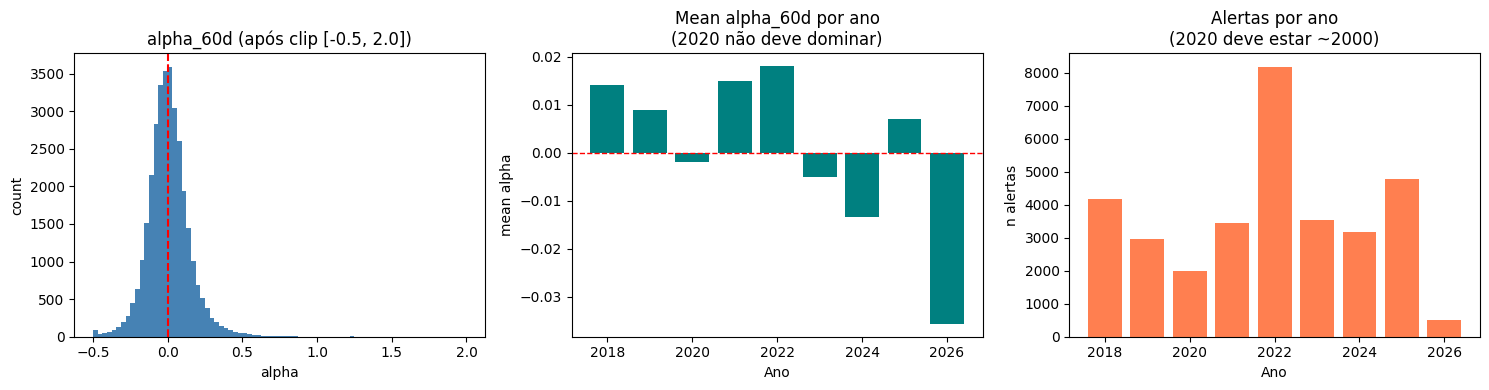


── Alpha stats ──────────────────────────
  Base rate (alpha > 5%) : 33.2%  ← modelo precisa de bater isto
  Mediana alpha_60d      : -0.000
  Média alpha_60d        : +0.007  ← se > 0 há selection bias nos alertas
  Alertas 2020           : 2000

── Top-10 correlações |feat vs alpha_60d| ──
drawdown_52w             0.109876
beta_60d                 0.092080
return_1m                0.086787
return_3m_pre            0.078143
sector_relative          0.054641
sector_alert_count_7d    0.040783
atr_ratio                0.034516
volume_spike             0.034212
drop_pct_today           0.026283
days_since_52w_high      0.009776

✅ Correlações razoáveis (max=0.110)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
import matplotlib.pyplot as plt

# 1. Distribuição do alpha_60d após winsorize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_v31['alpha_60d'], bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', lw=1.5, ls='--')
axes[0].set_title('alpha_60d (após clip [-0.5, 2.0])')
axes[0].set_xlabel('alpha'); axes[0].set_ylabel('count')

# 2. alpha_60d por ano — verifica se 2020 foi normalizado
yr_alpha = df_v31.groupby(df_v31['alert_date'].dt.year)['alpha_60d'].mean()
axes[1].bar(yr_alpha.index, yr_alpha.values, color='teal')
axes[1].axhline(0, color='red', lw=1, ls='--')
axes[1].set_title('Mean alpha_60d por ano\n(2020 não deve dominar)')
axes[1].set_xlabel('Ano'); axes[1].set_ylabel('mean alpha')

# 3. Alertas por ano após subsample
yr_counts = df_v31.groupby(df_v31['alert_date'].dt.year).size()
axes[2].bar(yr_counts.index, yr_counts.values, color='coral')
axes[2].set_title('Alertas por ano\n(2020 deve estar ~2000)')
axes[2].set_xlabel('Ano'); axes[2].set_ylabel('n alertas')

plt.tight_layout(); plt.show()

# 4. Percentagem de alpha_60d acima de 5% (base rate do problema)
base_rate = (df_v31['alpha_60d'] > 0.05).mean()
median_alpha = df_v31['alpha_60d'].median()
mean_alpha   = df_v31['alpha_60d'].mean()

print(f"\n── Alpha stats ──────────────────────────")
print(f"  Base rate (alpha > 5%) : {base_rate:.1%}  ← modelo precisa de bater isto")
print(f"  Mediana alpha_60d      : {median_alpha:+.3f}")
print(f"  Média alpha_60d        : {mean_alpha:+.3f}  ← se > 0 há selection bias nos alertas")
print(f"  Alertas 2020           : {(df_v31['alert_date'].dt.year == 2020).sum()}")

# 5. Correlação ingénua features vs alpha (data leakage check)
# Nenhuma feature deve ter |corr| > 0.4 — seria sinal de leakage
feat_corrs = df_v31[FEATURE_COLS_V31].corrwith(df_v31['alpha_60d']).abs().sort_values(ascending=False)
print(f"\n── Top-10 correlações |feat vs alpha_60d| ──")
print(feat_corrs.head(10).to_string())
if feat_corrs.max() > 0.4:
    print(f"\n🚨 ATENÇÃO: correlação > 0.4 detectada — suspeita de data leakage!")
else:
    print(f"\n✅ Correlações razoáveis (max={feat_corrs.max():.3f})")

## 📊 Célula 4 — Walk-forward CV + seleção do champion

In [15]:
import logging
from ml_training.models import build_model_configs
from ml_training.train import run_walk_forward_cv, summarize_results, select_champion
from ml_training.config import N_FOLDS, PURGE_DAYS

logging.basicConfig(level=logging.INFO, format='%(message)s')
assert not df_v31.empty, 'df_v31 está vazio — verifica a Célula 3'

model_configs = build_model_configs(
    feature_cols_v31=FEATURE_COLS_V31,
    feature_cols_baseline=FEATURE_COLS_BASELINE,
)
print(f'Modelos candidatos: {list(model_configs.keys())}')
print(f'CV: {N_FOLDS} folds, purge={PURGE_DAYS}d | Dataset: {len(df_v31)} amostras')
print('\nA correr walk-forward CV...')

results, oof_pred, fold_specs = run_walk_forward_cv(
    df_v31=df_v31,
    model_configs=model_configs,
    n_folds=N_FOLDS,
    purge_days=PURGE_DAYS,
)

summary = summarize_results(results)
print('\n=== Resumo CV ===')
print(summary.to_string(index=False))

Modelos candidatos: ['XGB-alpha-v31', 'LGBM-alpha-v31', 'RF-alpha-v31', 'Ridge-alpha-v31', 'XGB-alpha-baseline']
CV: 10 folds, purge=21d | Dataset: 32736 amostras

A correr walk-forward CV...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.91818e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.91818e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/s


=== Resumo CV ===
             model  rho_alpha_mean  rho_alpha_std  rho_down_mean  topk_pnl_mean  topk_pnl_std  n_folds
   Ridge-alpha-v31        0.083229       0.080892       0.206946       0.031679      0.032536       10
      RF-alpha-v31        0.057909       0.086031       0.184060       0.030320      0.032469       10
     XGB-alpha-v31        0.046721       0.079450       0.174901       0.024367      0.029412       10
XGB-alpha-baseline        0.043883       0.062655       0.163954       0.018600      0.029797       10
    LGBM-alpha-v31        0.038872       0.074595       0.164373       0.017240      0.031435       10


In [16]:
champion_name, champion_row = select_champion(summary)
print(f'\n🏆 Champion: {champion_name}')
print(f'   rho_alpha_mean : {champion_row["rho_alpha_mean"]:.4f}')
print(f'   topk_pnl_mean  : {champion_row["topk_pnl_mean"]:.4f}')
print(f'   n_folds        : {int(champion_row["n_folds"])}')


🏆 Champion: Ridge-alpha-v31
   rho_alpha_mean : 0.0832
   topk_pnl_mean  : 0.0317
   n_folds        : 10


In [17]:
for name, hist in results.items():
    if name != 'Ridge-alpha-v31':
        continue
    print(f"\n── {name} — fold-a-fold ──")
    for h in hist:
        rho = h['rho_alpha']
        pnl = h['topk_pnl']
        bar = '█' * int(max(rho * 200, 0))
        print(f"  Fold {h['fold']:2d} | rho={rho:+.4f} | pnl={pnl:+.4f} | {bar}")


── Ridge-alpha-v31 — fold-a-fold ──
  Fold  1 | rho=+0.0144 | pnl=+0.0252 | ██
  Fold  2 | rho=+0.0576 | pnl=+0.0336 | ███████████
  Fold  3 | rho=+0.0508 | pnl=+0.0134 | ██████████
  Fold  4 | rho=+0.0457 | pnl=+0.0282 | █████████
  Fold  5 | rho=+0.2040 | pnl=+0.0934 | ████████████████████████████████████████
  Fold  6 | rho=+0.0621 | pnl=-0.0141 | ████████████
  Fold  7 | rho=+0.1404 | pnl=+0.0240 | ████████████████████████████
  Fold  8 | rho=+0.2206 | pnl=+0.0891 | ████████████████████████████████████████████
  Fold  9 | rho=+0.0958 | pnl=+0.0032 | ███████████████████
  Fold 10 | rho=-0.0591 | pnl=+0.0206 | 


## 🎓 Célula 5 — Treino full + calibrador isotónico

In [18]:
import numpy as np
from ml_training.train import train_full_champion, fit_isotonic_calibrator

champion_cfg = model_configs[champion_name]
print('A treinar champion no dataset completo...')
champ_alpha, champ_down, feats_used, n_train = train_full_champion(df_v31, champion_cfg)
print(f'✅ Treinado: {n_train} amostras, {len(feats_used)} features')

oof_champion = oof_pred[champion_name]
alpha_true = df_v31['alpha_60d'].values

iso_model, brier_oof, n_oof = fit_isotonic_calibrator(
    oof_pred_champion=oof_champion,
    alpha_true=alpha_true,
    alpha_threshold=0.05,
)
print(f'✅ Calibrador OOF: brier={brier_oof:.4f}, n_oof={n_oof}')

valid_mask = np.isfinite(oof_champion)
win_rate_alpha = float((alpha_true[valid_mask] > 0.05).mean()) if valid_mask.sum() > 0 else 0.0
print(f'   win_rate_alpha (>5%): {win_rate_alpha:.3f}')

A treinar champion no dataset completo...
✅ Treinado: 32736 amostras, 29 features
✅ Calibrador OOF: brier=0.2198, n_oof=17121
   win_rate_alpha (>5%): 0.328


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.90737e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.90737e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


## 📦 Célula 6 — Bundle + Report

In [20]:
from datetime import datetime, timezone
from ml_training.bundle import DipModelsV3, save_bundle, build_report, save_report
from ml_training.config import HORIZON_DAYS, MOMENTUM_FEATURES

champ_hist = results[champion_name]
rho_alpha_vals = [h['rho_alpha'] for h in champ_hist if np.isfinite(h['rho_alpha'])]
rho_down_vals  = [h['rho_down']  for h in champ_hist if np.isfinite(h['rho_down'])]
pnl_vals       = [h['topk_pnl']  for h in champ_hist if np.isfinite(h['topk_pnl'])]

bundle = DipModelsV3(
    model_up         = champ_alpha,
    model_down       = champ_down,
    feature_cols     = feats_used,
    score_calibrator = iso_model,
    n_train_samples  = n_train,
    train_date = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ'),
    champion_name    = champion_name,
    schema_version   = 3,
    momentum_feats   = MOMENTUM_FEATURES,
    rho_mean         = float(np.mean(rho_alpha_vals)) if rho_alpha_vals else None,
    rho_alpha        = float(np.mean(rho_alpha_vals)) if rho_alpha_vals else None,
    rho_down         = float(np.mean(rho_down_vals))  if rho_down_vals  else None,
    topk_pnl         = float(np.mean(pnl_vals))       if pnl_vals       else None,
    fold_metrics     = champ_hist,
)

PKL_PATH    = Path('/content/dip_models_v3.pkl')
REPORT_PATH = Path('/content/ml_report_v3.json')

save_bundle(bundle, PKL_PATH)
print(f'✅ Bundle: {PKL_PATH} ({PKL_PATH.stat().st_size/1024:.1f} KB)')

report = build_report(
    bundle         = bundle,
    summary_df     = summary,
    brier_oof      = brier_oof,
    win_rate_alpha = win_rate_alpha,
    n_folds_used   = len(champ_hist),
    purge_days     = PURGE_DAYS,
    horizon_days   = HORIZON_DAYS,
    new_features   = _extra,
)
save_report(report, REPORT_PATH)
print(f'✅ Report: {REPORT_PATH}')
print(f"   Champion : {report['champion']}")
print(f"   rho_alpha: {report['metrics']['rho_alpha_mean']}")
print(f"   topk_pnl : {report['metrics']['topk_pnl_mean']}")

✅ Bundle: /content/dip_models_v3.pkl (3.1 KB)
✅ Report: /content/ml_report_v3.json
   Champion : Ridge-alpha-v31
   rho_alpha: 0.08322890609455921
   topk_pnl : 0.03167872217126346


## 💾 Célula 7 — Guardar ml_training_base.parquet

In [21]:
PARQUET_PATH = Path('/content/ml_training_base.parquet')
df_v31.to_parquet(PARQUET_PATH, index=False)
print(f'✅ ml_training_base.parquet: {PARQUET_PATH.stat().st_size/1024:.0f} KB')
print(f'   Linhas  : {len(df_v31)}')
print(f'   Colunas : {len(df_v31.columns)}')

✅ ml_training_base.parquet: 3606 KB
   Linhas  : 32736
   Colunas : 36


## 📤 Célula 8A — Download direto

In [ ]:
from google.colab import files
files.download(str(PKL_PATH))
files.download(str(REPORT_PATH))
files.download(str(PARQUET_PATH))
print('✅ Downloads iniciados: pkl + json + parquet')

## 🚀 Célula 8B — Push automático para GitHub

In [22]:
import base64, json as _json, requests as _req
from datetime import datetime as _dt

GH_API  = 'https://api.github.com'
HEADERS = {'Authorization': f'token {GITHUB_TOKEN}', 'Accept': 'application/vnd.github.v3+json'}

def gh_get_sha(filepath):
    r = _req.get(f'{GH_API}/repos/{REPO_OWNER}/{REPO_NAME}/contents/{filepath}',
                 headers=HEADERS, params={'ref': BRANCH})
    return r.json().get('sha') if r.status_code == 200 else None

def gh_push_file(filepath, local_path, msg):
    content_b64 = base64.b64encode(local_path.read_bytes()).decode()
    sha = gh_get_sha(filepath)
    payload = {'message': msg, 'content': content_b64, 'branch': BRANCH}
    if sha: payload['sha'] = sha
    r = _req.put(f'{GH_API}/repos/{REPO_OWNER}/{REPO_NAME}/contents/{filepath}',
                 headers=HEADERS, data=_json.dumps(payload))
    verb = 'Atualizado' if sha else 'Criado'
    if r.status_code in (200, 201): print(f'  ✅ {verb}: {filepath}')
    else: print(f'  ❌ {filepath}: {r.status_code} {r.text[:200]}')

ts       = _dt.utcnow().strftime('%Y-%m-%d %H:%M UTC')
rho_str  = f'{bundle.rho_alpha:.4f}' if bundle.rho_alpha is not None else 'N/A'
commit_msg = f'chore(ml): retrain [{ts}] champion={champion_name} rho={rho_str}'

print(f'Push para {REPO_OWNER}/{REPO_NAME}@{BRANCH}')
print(f'Commit: {commit_msg}\n')
gh_push_file('dip_models_v3.pkl',        PKL_PATH,     commit_msg)
gh_push_file('ml_report_v3.json',        REPORT_PATH,  commit_msg)
gh_push_file('ml_training_base.parquet', PARQUET_PATH, commit_msg)
print('\n🚀 Push concluído — Railway irá redeploy automaticamente.')

/tmp/ipykernel_356/1129567520.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts       = _dt.utcnow().strftime('%Y-%m-%d %H:%M UTC')


Push para romeurf/DipRadar@main
Commit: chore(ml): retrain [2026-05-06 11:01 UTC] champion=Ridge-alpha-v31 rho=0.0832

  ✅ Atualizado: dip_models_v3.pkl
  ✅ Atualizado: ml_report_v3.json
  ✅ Atualizado: ml_training_base.parquet

🚀 Push concluído — Railway irá redeploy automaticamente.
